## Econ 522 Lab — Week 5

Today, we will discuss

1. Simulate MA and AR/ARMA processes
2. Compute multi-step-ahead point forecasts from ARMA models
3. Evaluate forecasts using bias, MSE, RMSE
4. Perform the Diebold-Mariano test to compare two competing forecasts

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy import stats

---
Before forecasting, we need data. We will simulate three processes covered in lecture:
- **MA(2)**: $y_t = \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2}$
- **AR(1)**: $y_t = \phi y_{t-1} + \varepsilon_t$
- **ARMA(1,1)**: $y_t = \phi y_{t-1} + \varepsilon_t + \theta \varepsilon_{t-1}$

In all cases $\varepsilon_t \sim WN(0, \sigma^2)$.

We manually construct the MA(2) so you can see exactly what is happening.

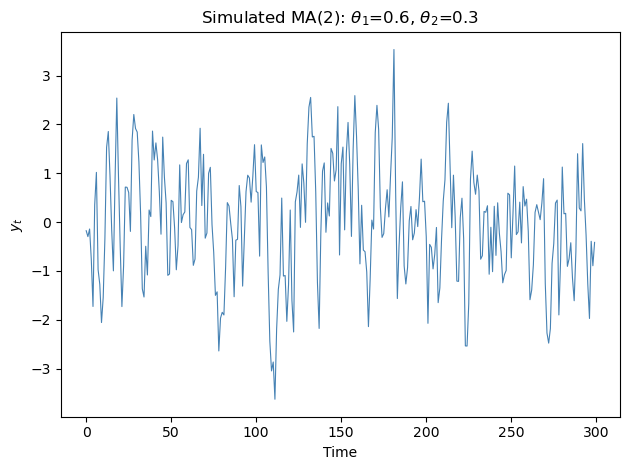

Mean: 0.0019   Std: 1.1849


In [22]:
# ── Parameters ──────────────────────────────────────────────
T      = 300          # number of observations
sigma  = 1.0          # std dev of white noise
theta1 = 0.6          # MA(1) coefficient
theta2 = 0.3          # MA(2) coefficient

# ── Simulate white noise ─────────────────────────────────────
eps = np.random.normal(0, sigma, T + 2)   # extra 2 for burn-in

# ── Build the MA(2) series ───────────────────────────────────
# y_t = eps_t + theta1*eps_{t-1} + theta2*eps_{t-2}
y_ma2 = np.array([
    eps[t] + theta1 * eps[t-1] + theta2 * eps[t-2]
    for t in range(2, T + 2)
])

# ── Plot ─────────────────────────────────────────────────────
plt.plot(y_ma2, color='steelblue', lw=0.8)
plt.title(rf'Simulated MA(2): $\theta_1$={theta1}, $\theta_2$={theta2}')
plt.xlabel('Time'); plt.ylabel('$y_t$')
plt.tight_layout(); plt.show()
print(f'Mean: {y_ma2.mean():.4f}   Std: {y_ma2.std():.4f}')

Now, simulate an AR(1) Process. For stationarity we need $|\phi| < 1$.

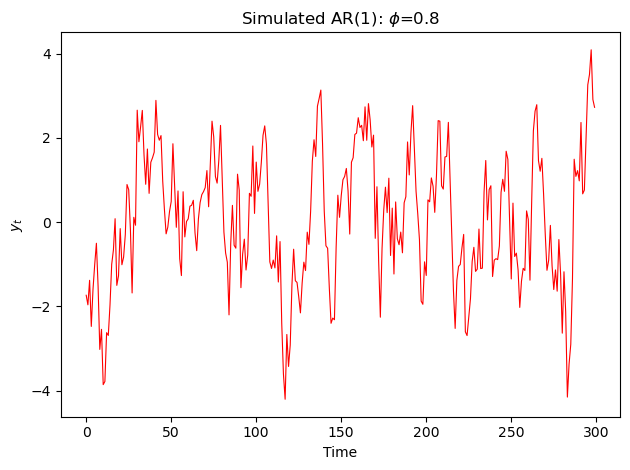

In [23]:
phi   = 0.8     # AR coefficient  (|phi| < 1 for stationarity)
eps2  = np.random.normal(0, sigma, T)

y_ar1 = np.zeros(T)
y_ar1[0] = eps2[0]                          # initialise
for t in range(1, T):
    y_ar1[t] = phi * y_ar1[t-1] + eps2[t]  # y_t = phi*y_{t-1} + eps_t

plt.plot(y_ar1, color='red', lw=0.8)
plt.title(rf'Simulated AR(1): $\phi$={phi}')
plt.xlabel('Time'); plt.ylabel('$y_t$')
plt.tight_layout(); plt.show()

Simulate an ARMA(1,1) Process

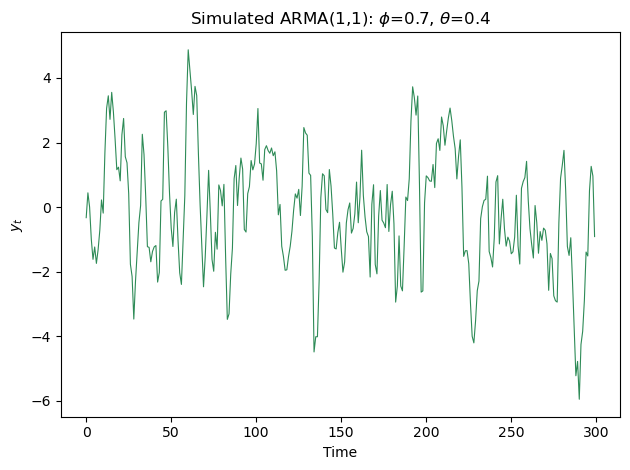

In [24]:
phi_a  = 0.7    # AR coefficient
theta_a = 0.4   # MA coefficient
eps3   = np.random.normal(0, sigma, T)

y_arma = np.zeros(T)
y_arma[0] = eps3[0]
for t in range(1, T):
    # y_t = phi*y_{t-1} + eps_t + theta*eps_{t-1}
    y_arma[t] = phi_a * y_arma[t-1] + eps3[t] + theta_a * eps3[t-1]

plt.plot(y_arma, color='seagreen', lw=0.8)
plt.title(rf'Simulated ARMA(1,1): $\phi$={phi_a}, $\theta$={theta_a}')
plt.xlabel('Time'); plt.ylabel('$y_t$')
plt.tight_layout(); plt.show()

We now apply the forecasting formulas from the lecture slides.

Forecasting with MA(2) — by hand

From the slides, the forecasts at time $T$ are:

| Horizon $h$ | Forecast $y_{T+h,T}$ |
|:-----------:|:--------------------:|
| 1           | $\theta_1 \varepsilon_T + \theta_2 \varepsilon_{T-1}$ |
| 2           | $\theta_2 \varepsilon_T$ |
| $h > 2$    | $0$ (long-run mean) |

And the forecast error variances:

| Horizon $h$ | $\sigma^2_h$ |
|:-----------:|:------------:|
| 1           | $\sigma^2$ |
| 2           | $\sigma^2(1 + \theta_1^2)$ |
| $h > 2$    | $\sigma^2(1 + \theta_1^2 + \theta_2^2)$ — unconditional variance |

In [25]:
# We treat the last observation as time T
T_idx = len(y_ma2) - 1   # index of T in our array

# The last two shocks (eps_T and eps_{T-1})
eps_T   = eps[T_idx + 1]   # eps at time T  (offset by 2 from eps array)
eps_Tm1 = eps[T_idx]       # eps at time T-1

# ── Compute forecasts ────────────────────────────────────────
fc_h1 = theta1 * eps_T + theta2 * eps_Tm1     # 1-step
fc_h2 = theta2 * eps_T                         # 2-step
fc_h3 = 0.0                                    # 3+ step: long-run mean

# ── Compute forecast error std deviations ────────────────────
sigma2_h1 = sigma**2
sigma2_h2 = sigma**2 * (1 + theta1**2)
sigma2_h3 = sigma**2 * (1 + theta1**2 + theta2**2)   # unconditional var

print('MA(2) Forecasts from time T')
print('='*45)
print(f'  h=1  forecast: {fc_h1:+.4f}   σ_h = {np.sqrt(sigma2_h1):.4f}')
print(f'  h=2  forecast: {fc_h2:+.4f}   σ_h = {np.sqrt(sigma2_h2):.4f}')
print(f'  h=3+ forecast: {fc_h3:+.4f}   σ_h = {np.sqrt(sigma2_h3):.4f}')

MA(2) Forecasts from time T
  h=1  forecast: -0.3338   σ_h = 1.0000
  h=2  forecast: -0.2671   σ_h = 1.1662
  h=3+ forecast: +0.0000   σ_h = 1.2042


Forecasting with AR(1) using statsmodels

For AR and ARMA models it is more practical to use `statsmodels.ARIMA`. 
We split the data into a **training set** (first 250 obs) and a **test set** (last 50 obs) to do pseudo-out-of-sample evaluation.

In [49]:
# ── Train / test split ───────────────────────────────────────
train_end = 250
y_train = y_ar1[:train_end]
y_test  = y_ar1[train_end:]
H       = len(y_test)          # number of out-of-sample steps

# ── Fit AR(1) on training data ───────────────────────────────
# ARIMA(p, d, q): p=1, d=0 (stationary), q=0
model_ar1 = ARIMA(y_train, order=(1, 0, 0))
res_ar1   = model_ar1.fit()

print(res_ar1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  250
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -324.332
Date:                Fri, 20 Feb 2026   AIC                            654.664
Time:                        09:50:53   BIC                            665.229
Sample:                             0   HQIC                           658.916
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0380      0.291      0.131      0.896      -0.533       0.609
ar.L1          0.8108      0.041     19.861      0.000       0.731       0.891
sigma2         0.7807      0.076     10.292      0.0

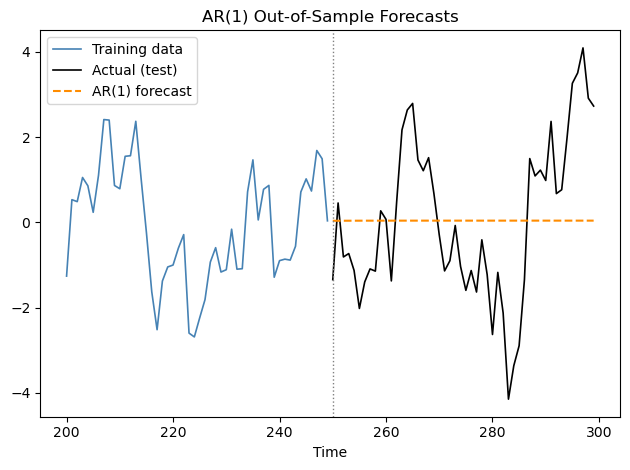

In [53]:
# ── Produce H-step-ahead forecasts ───────────────────────────
fc_ar1 = res_ar1.forecast(steps=H)          # point forecasts
ci_ar1 = res_ar1.get_forecast(steps=H).conf_int(alpha=0.05)  # 95% CI

# ── Visualise ────────────────────────────────────────────────
t_train = np.arange(train_end)
t_test  = np.arange(train_end, T)

fig, ax = plt.subplots()
ax.plot(t_train[-50:], y_train[-50:], color='steelblue', lw=1.2, label='Training data')
ax.plot(t_test, y_test, color='black', lw=1.2, label='Actual (test)')
ax.plot(t_test, fc_ar1, color='darkorange', lw=1.5, ls='--', label='AR(1) forecast')
ax.axvline(train_end, color='grey', ls=':', lw=1)
ax.legend(); ax.set_xlabel('Time'); ax.set_title('AR(1) Out-of-Sample Forecasts')
plt.tight_layout(); plt.show()

### 2.3 Forecasting with ARMA(1,1)

From the slides:
- $y_{T+1,T} = \phi y_T + \theta \varepsilon_T$
- $y_{T+h,T} = \phi \, y_{T+h-1,T}$ for $h > 1$  (MA part drops out)

The 2-step forecast error variance uses the MA representation coefficient $b_1 = (\phi + \theta)$.

In [57]:
y_train_a = y_arma[:train_end]
y_test_a  = y_arma[train_end:]

# ARIMA(1, 0, 1) = ARMA(1,1)
model_arma = ARIMA(y_train_a, order=(1, 0, 1))
res_arma   = model_arma.fit()

phi_hat_a   = res_arma.params[1]
theta_hat_a = res_arma.params[2]
sigma_hat_a = np.sqrt(res_arma.params[3])

print(f'Estimated phi:   {phi_hat_a:.4f}  (true: {phi_a})')
print(f'Estimated theta: {theta_hat_a:.4f}  (true: {theta_a})')

Estimated phi:   0.6979  (true: 0.7)
Estimated theta: 0.3808  (true: 0.4)


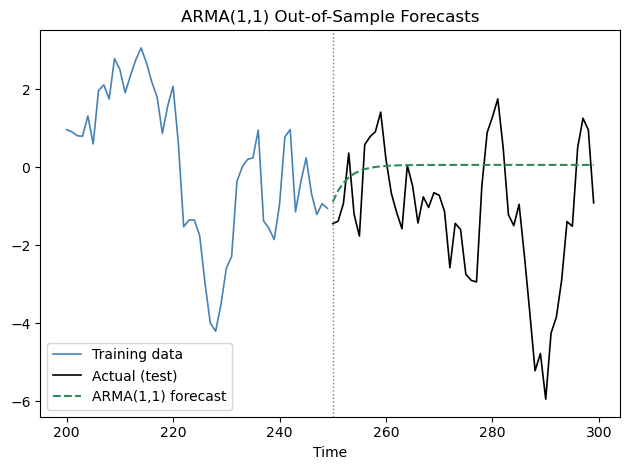

In [58]:
fc_arma = res_arma.forecast(steps=H)
ci_arma = res_arma.get_forecast(steps=H).conf_int(alpha=0.05)

fig, ax = plt.subplots()
ax.plot(t_train[-50:], y_train_a[-50:], color='steelblue', lw=1.2, label='Training data')
ax.plot(t_test, y_test_a, color='black', lw=1.2, label='Actual (test)')
ax.plot(t_test, fc_arma, color='seagreen', lw=1.5, ls='--', label='ARMA(1,1) forecast')
ax.axvline(train_end, color='grey', ls=':', lw=1)
ax.legend(); ax.set_xlabel('Time'); ax.set_title('ARMA(1,1) Out-of-Sample Forecasts')
plt.tight_layout(); plt.show()

---
We now evaluate forecasts using the tools from the **Forecast Evaluation** lecture slides.

We compare two models on the AR(1) data:
- **Model A**: our fitted AR(1)
- **Model B (naive)**: the random-walk "no-change" forecast $\hat{y}_{T+h} = y_T$

In [59]:
# ── Pseudo out-of-sample: rolling 1-step forecasts ──────────
# We re-estimate the AR(1) at each step — the realistic scenario.

oos_start = train_end
oos_end   = T
n_oos     = oos_end - oos_start

fc_a_1step  = np.zeros(n_oos)   # AR(1) 1-step forecasts
fc_b_1step  = np.zeros(n_oos)   # naive no-change forecasts

for i in range(n_oos):
    t = oos_start + i
    y_window = y_ar1[:t]               # expanding window

    # Model A: AR(1)
    res_tmp = ARIMA(y_window, order=(1,0,0)).fit()
    fc_a_1step[i] = res_tmp.forecast(steps=1)[0]

    # Model B: naive (no-change)
    fc_b_1step[i] = y_ar1[t-1]        # y_{T+1} = y_T

# actual realisations in OOS period
y_actual = y_ar1[oos_start:oos_end]

# forecast errors: e = actual - forecast
err_a = y_actual - fc_a_1step
err_b = y_actual - fc_b_1step

print(f'Out-of-sample period: t = {oos_start} to {oos_end-1}  ({n_oos} observations)')

Out-of-sample period: t = 250 to 299  (50 observations)


From the slides:
- **Bias** = $\bar{e} = \frac{1}{T}\sum e_{t+1,t}$
- **MSE** = $\frac{1}{T}\sum e_{t+1,t}^2 = \sigma^2_e + \bar{e}^2$
- **RMSE** = $\sqrt{\text{MSE}}$
- **MAE** = $\frac{1}{T}\sum |e_{t+1,t}|$

In [61]:
def forecast_metrics(errors, label=''):
    """Compute and print key forecast accuracy metrics."""
    bias = errors.mean()
    mse  = (errors**2).mean()
    rmse = np.sqrt(mse)
    mae  = np.abs(errors).mean()
    # Verify decomposition: MSE = Var(e) + Bias^2
    mse_check = errors.var() + bias**2

    print(f'\n── {label} ──')
    print(f'  Bias  : {bias:+.6f}')
    print(f'  MSE   : {mse:.6f} ')
    print(f'  RMSE  : {rmse:.6f}')
    print(f'  MAE   : {mae:.6f}')
    return dict(bias=bias, mse=mse, rmse=rmse, mae=mae)

m_a = forecast_metrics(err_a, 'Model A — AR(1)')
m_b = forecast_metrics(err_b, 'Model B — Naive (no-change)')


── Model A — AR(1) ──
  Bias  : +0.051504
  MSE   : 1.097578 
  RMSE  : 1.047654
  MAE   : 0.845489

── Model B — Naive (no-change) ──
  Bias  : +0.053840
  MSE   : 1.162563 
  RMSE  : 1.078222
  MAE   : 0.885599


### 3.3 Checking Forecast Error Properties

From the slides, optimal 1-step-ahead forecast errors should be:
1. **Zero-mean** (unbiased)
2. **White noise** (serially uncorrelated)

We check with an ACF plot and a t-test on the mean.

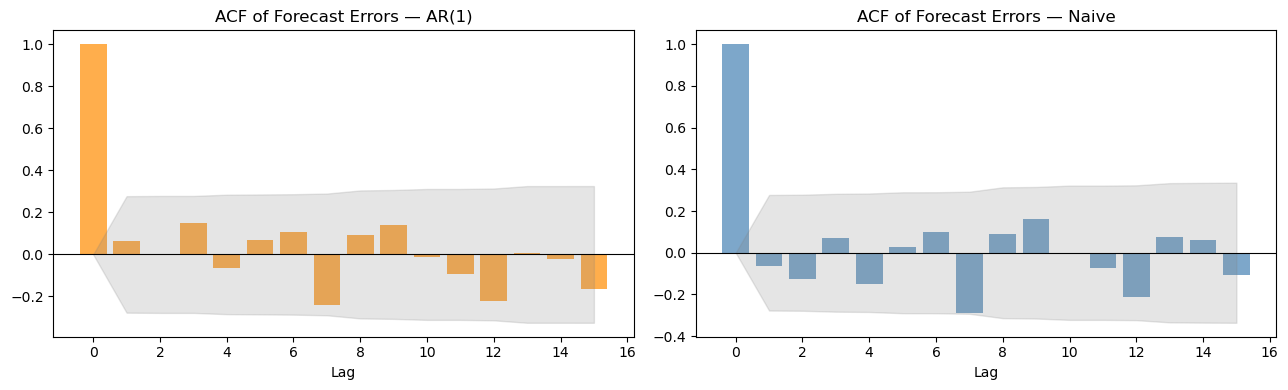

AR(1)     | Mean=+0.0515  t=0.345  p=0.732  DW=1.832
Naive     | Mean=+0.0538  t=0.350  p=0.728  DW=2.087


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, err, label, color in zip(
        axes,
        [err_a,       err_b],
        ['AR(1)',      'Naive'],
        ['darkorange', 'steelblue']):

    lags_to_plot = 15
    acf_vals, confint = acf(err, nlags=lags_to_plot, alpha=0.05)

    ax.bar(range(lags_to_plot+1), acf_vals, color=color, alpha=0.7)
    ax.fill_between(range(lags_to_plot+1),
                    confint[:,0]-acf_vals, confint[:,1]-acf_vals,
                    alpha=0.2, color='grey')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'ACF of Forecast Errors — {label}'); ax.set_xlabel('Lag')

plt.tight_layout(); plt.show()

# t-test for zero mean
for err, label in [(err_a, 'AR(1)'), (err_b, 'Naive')]:
    t_stat, p_val = stats.ttest_1samp(err, 0)
    dw = durbin_watson(err)
    print(f'{label:8s}  | Mean={err.mean():+.4f}  t={t_stat:.3f}  p={p_val:.3f}  DW={dw:.3f}')

---
We now formally test whether AR(1) is **significantly** more accurate than the naive forecast.

The DM statistic is:
$$\text{DM} = \frac{\bar{d}_{12}}{\hat{\sigma}_{\bar{d}_{12}}} \xrightarrow{d} N(0,1)$$

where $d_{12t} = L(e^{A}_t) - L(e^{B}_t)$ is the loss differential at time $t$.

Under **quadratic loss**, $d_{12t} = (e^A_t)^2 - (e^B_t)^2$.

$H_0$: Equal predictive accuracy &nbsp;&nbsp;&nbsp; $H_1$: AR(1) is more accurate

In [69]:
def dm_test(err_a, err_b, h=1, loss='quadratic'):
    """
    Diebold-Mariano test.
    H0: E[L(e_a)] = E[L(e_b)]  (equal predictive accuracy)
    H1: Model A is more accurate (d < 0 under quadratic loss)

    Uses HAC standard errors via OLS regression of d on a constant.
    """
    if loss == 'quadratic':
        d = err_a**2 - err_b**2
    elif loss == 'absolute':
        d = np.abs(err_a) - np.abs(err_b)
    else:
        raise ValueError('loss must be quadratic or absolute')

    # HAC SE: regress d on a constant, get robust SE
    reg = OLS(d, np.ones(len(d))).fit(cov_type='HAC',
                                       cov_kwds={'maxlags': h})
    d_bar  = reg.params[0]
    se_d   = reg.bse[0]
    dm_stat = d_bar / se_d
    p_two   = 2 * stats.norm.cdf(-abs(dm_stat))    # two-sided p-value
    p_one   = stats.norm.cdf(dm_stat)              # one-sided: H1 = A better

    print('Diebold-Mariano Test')
    print('='*40)
    print(f'  Loss function : {loss}')
    print(f'  Mean d̄₁₂     : {d_bar:+.6f}')
    print(f'  HAC SE        : {se_d:.6f}')
    print(f'  DM statistic  : {dm_stat:+.4f}')
    print(f'  p-value (two-sided): {p_two:.4f}')
    print(f'  p-value (H1: A better): {p_one:.4f}')
    print()
    if p_one < 0.05:
        print('  → Reject H₀ at 5%: Model A (AR(1)) is significantly more accurate ✓')
    else:
        print('  → Fail to reject H₀: No significant difference in accuracy')
    return dm_stat, p_two

dm_stat, dm_pval = dm_test(err_a, err_b, h=1, loss='quadratic')

Diebold-Mariano Test
  Loss function : quadratic
  Mean d̄₁₂     : -0.064985
  HAC SE        : 0.090589
  DM statistic  : -0.7174
  p-value (two-sided): 0.4732
  p-value (H1: A better): 0.2366

  → Fail to reject H₀: No significant difference in accuracy
